In [2]:
import os

import pandas as pd
import numpy as np
import torch

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate ,StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix    

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

os.system(
    "kaggle competitions download -c titanic -p data/"
)

titanic.zip: Skipping, found more recently modified local copy (use --force to force download)


0

In [4]:
import zipfile

with zipfile.ZipFile("data/titanic.zip", "r") as zip_ref:
    zip_ref.extractall("data/")
df = pd.read_csv("data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## EDA

In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [7]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


We can see the data is imbalanced, so when we split the data we will use stratify

[Text(0, 0, 'Did Not Survive'), Text(1, 0, 'Survived')]

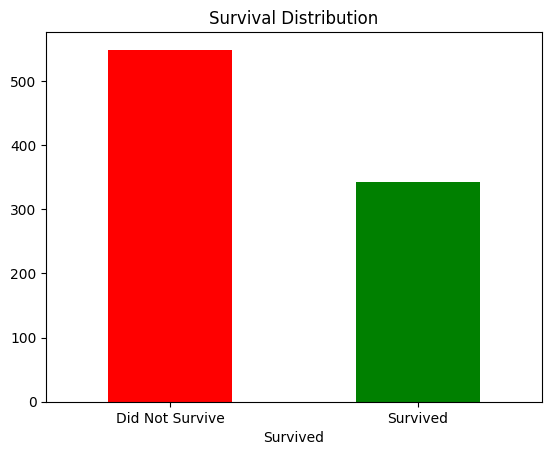

In [9]:
df['Survived'].value_counts().plot(kind='bar', color=['red','green'], title='Survival Distribution').set_xticklabels(['Did Not Survive', 'Survived'], rotation=0)

Lets look at some instances from the different classes to see if we notice notable differences:

In [10]:
sur_df = df[df['Survived'] == 1]
no_sur_df = df[df['Survived'] == 0]

In [11]:
sur_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C


In [12]:
no_sur_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
18,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S


In [13]:
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Pclass', 'Embarked']

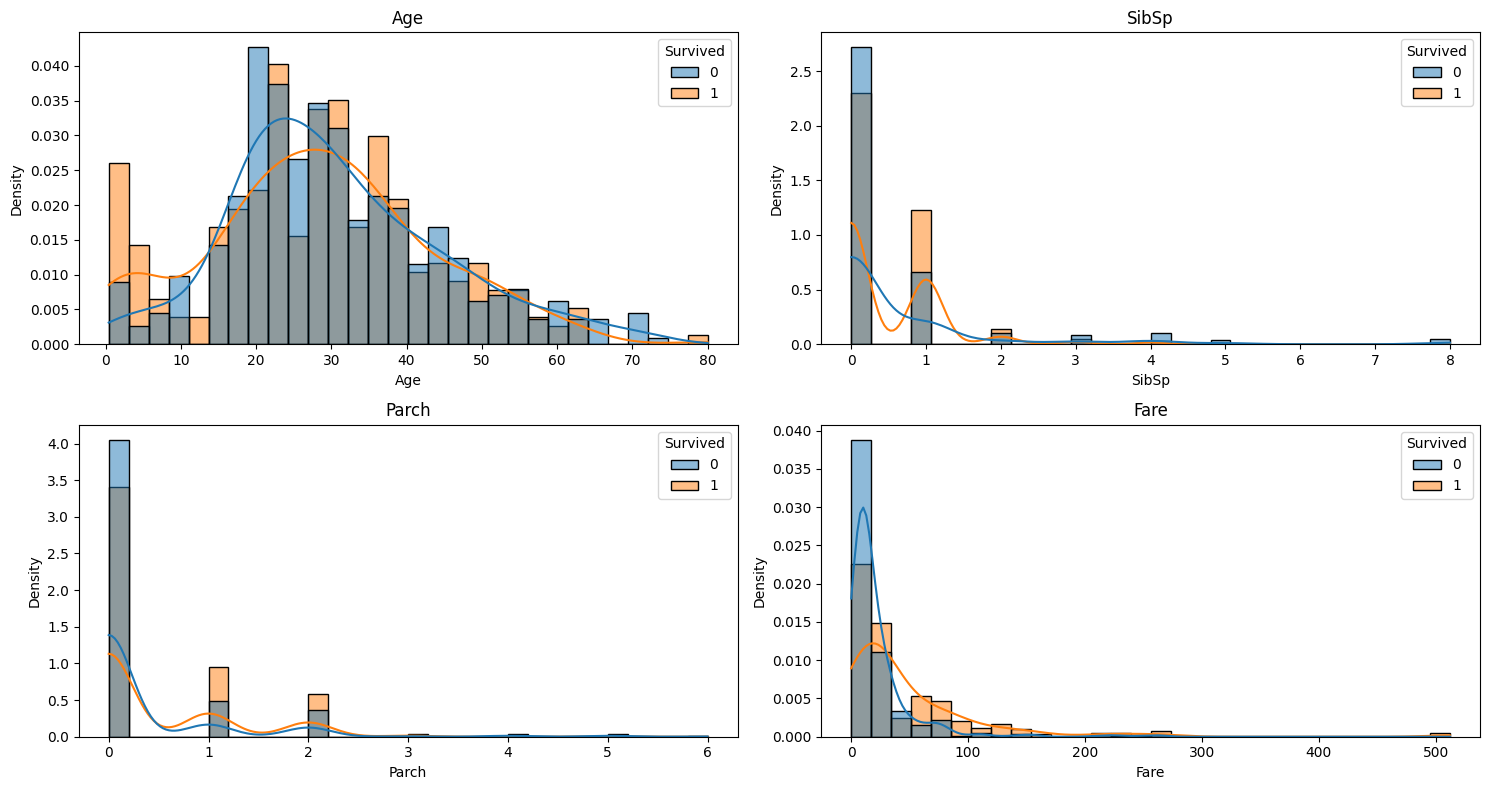

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 4 * 2))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        hue='Survived',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

We can see that most of the children survived, on the other hand most of the 20yo didnt survive.
Also, the ones that paied less, were most likely non-survivals.

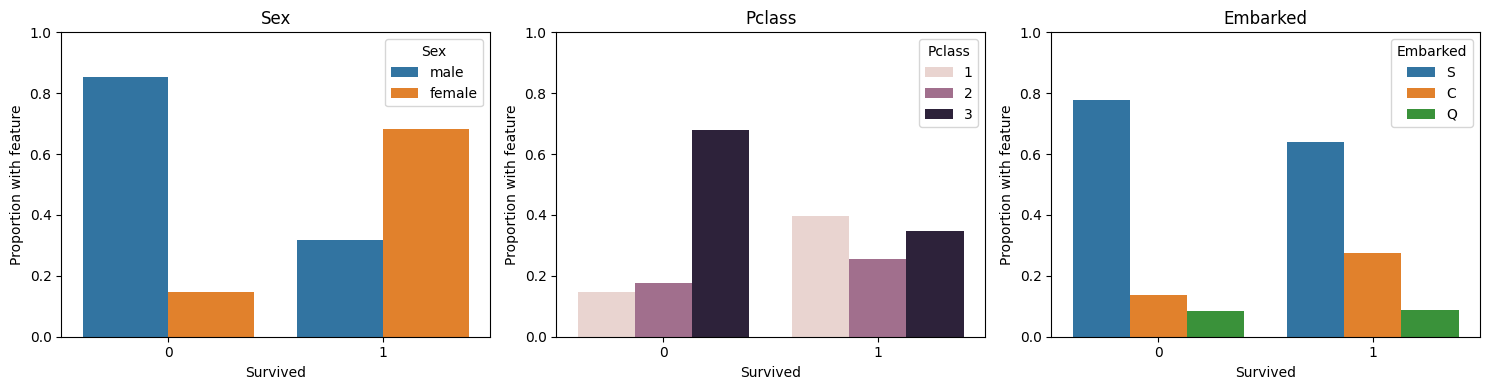

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    rates = (
        df.groupby('Survived')[feature]
        .value_counts(normalize=True)
        .rename('Proportion')
        .reset_index()
    )

    sns.barplot(
        data=rates,
        x='Survived',
        y='Proportion',
        hue=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_ylabel('Proportion with feature')
    axes[i].set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

We can see some interesting things in the plots, most of the females survived - unlike the males, also most of the non surviving people are from class 3.

<Axes: xlabel='Pclass', ylabel='Age'>

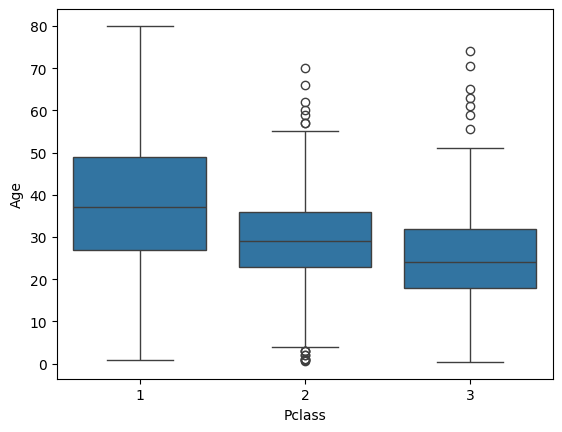

In [16]:
sns.boxplot(x="Pclass", y="Age", data=df)

Here we see the relation between age and pclass, from that we can impute the age column

In [17]:
df.groupby(["Sex","Pclass"])["Age"].describe()

count       mean        std   min     25%   50%    75%   max
Sex    Pclass                                                              
female 1        85.0  34.611765  13.612052  2.00  23.000  35.0  44.00  63.0
       2        74.0  28.722973  12.872702  2.00  22.250  28.0  36.00  57.0
       3       102.0  21.750000  12.729964  0.75  14.125  21.5  29.75  63.0
male   1       101.0  41.281386  15.139570  0.92  30.000  40.0  51.00  80.0
       2        99.0  30.740707  14.793894  0.67  23.000  30.0  36.75  70.0
       3       253.0  26.507589  12.159514  0.42  20.000  25.0  33.00  74.0

In [18]:
missing_pct = (
    df.isnull().mean()
      .sort_values(ascending=False)
)
missing_pct

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
dtype: float64

In [19]:
df[df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


## Feature Engineering

- 'Age' contains about 20% missing values and is likely predictive of survival, so I will impute rather than remove the feature
- 'Cabin' on the other hand contains 77% missing values, hence I will remove it or use it as a binary feature indicating whether thare is a cabin or not.
- 'Embaked' is missing 2 values, which seems to be females with a high fare, so we can assume they from Cherbourg (C)

'Name' containes a lot of hidden information, age, sex and social status, hence we will create a new feature out of it named 'Title'

'SibSp' and 'Parch' describe ones company on the Titanic, we can create a new feature out of it containing both

'Ticket' can be devided into 'Ticket number' and 'Ticket prefix'

In [20]:
def preprocess(df):
    # A more sophisticated approach could use passenger titles extracted from names.
    # However, to keep preprocessing simple and interpretable, age was imputed using demographic groups defined by Sex and Pclass.
    df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

    df['HasCabin'] = df['Cabin'].notna().astype(int)

    df.loc[df['Embarked'].isna(), 'Embarked'] = 'C'

    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
    # print('\nUnique Titles: \n', df['Title'].value_counts())
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    rare_titles = ['Dr', 'Rev', 'Major', 'Col', 'Don', 'Lady', 'Sir', 'Capt', 'the Countess', 'Jonkheer']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    # print('\nRare Replacement Titles: \n', df['Title'].value_counts())

    df['FamilySize'] = (df['SibSp'] + df['Parch'] + 1)


    df = df.drop(['Name', 'PassengerId', 'Ticket', 'Cabin'], axis=1)

    return df

In [21]:
df = preprocess(df)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Title,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,0,Mr,2
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs,2
2,1,3,female,26.0,0,0,7.9250,S,0,Miss,1
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs,2
4,0,3,male,35.0,0,0,8.0500,S,0,Mr,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,0,Rare,1
887,1,1,female,19.0,0,0,30.0000,S,1,Miss,1
888,0,3,female,21.5,1,2,23.4500,S,0,Miss,4
889,1,1,male,26.0,0,0,30.0000,C,1,Mr,1


<Axes: xlabel='FamilySize', ylabel='Density'>

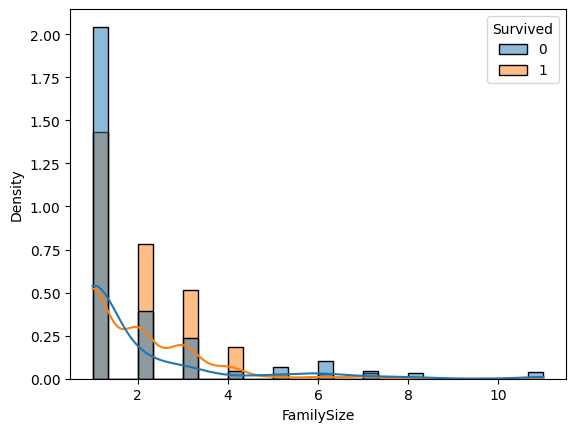

In [22]:
sns.histplot(
        data=df,
        x='FamilySize',
        hue='Survived',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False
    )

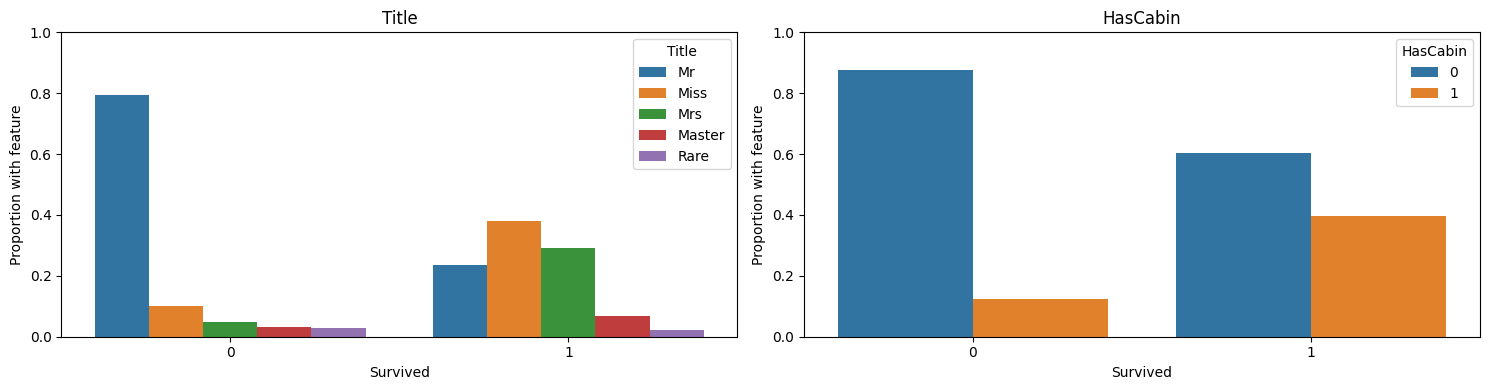

In [23]:
new_cat = ['Title', 'HasCabin']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes = axes.flatten()

for i, feature in enumerate(new_cat):
    rates = (
        df.groupby('Survived')[feature]
        .value_counts(normalize=True)
        .rename('Proportion')
        .reset_index()
    )

    sns.barplot(
        data=rates,
        x='Survived',
        y='Proportion',
        hue=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_ylabel('Proportion with feature')
    axes[i].set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'C': 2, 'Q': 1, 'S': 0})

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'HasCabin', 'Title', 'FamilySize'],
      dtype='str')

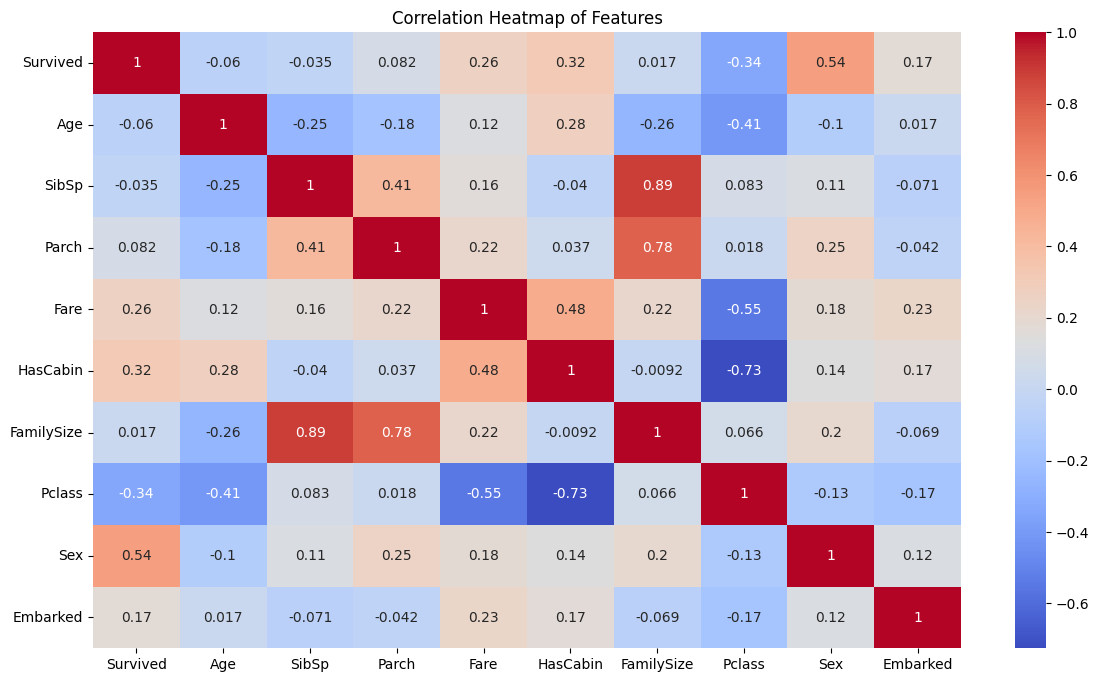

In [33]:
corr_df = df[['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'Pclass', 'Sex', 'Embarked']]
plt.figure(figsize=(14, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()